<a href="https://colab.research.google.com/github/Harsh11204/Machine-Learning-Based-Train-Journey-Time-Prediction-System/blob/main/ML_Based_Train_Journey_Time_Prediction_System.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Import Required Libraries**

In [65]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import pickle

# **Level 1 : Understanding the Data**

# Task 1.1: Check the dataset for total records and columns

In [2]:
# Load the Dataset
df = pd.read_csv("Dataset1.csv")
df.head()

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance
0,1,107,SWV,100,100,100,100,SAWANTWADI R,1,00:00:00,10:25:00,0
1,2,107,THVM,260,228,196,164,THIVIM,1,11:06:00,11:08:00,32
2,3,107,KRMI,345,296,247,198,KARMALI,1,11:28:00,11:30:00,49
3,4,107,MAO,490,412,334,256,MADGOAN JN.,1,12:10:00,00:00:00,78
4,1,108,MAO,100,100,100,100,MADGOAN JN.,1,00:00:00,20:30:00,0


In [3]:
# Dataset Shape
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 186074
Number of Columns: 12


In [4]:
# Display Column Names
print(df.columns.tolist())

['SN', 'Train_No', 'Station_Code', '1A', '2A', '3A', 'SL', 'Station_Name', 'Route_Number', 'Arrival_time', 'Departure_Time', 'Distance']


In [5]:
# Data types
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186074 entries, 0 to 186073
Data columns (total 12 columns):
 #   Column          Non-Null Count   Dtype 
---  ------          --------------   ----- 
 0   SN              186074 non-null  int64 
 1   Train_No        186074 non-null  int64 
 2   Station_Code    186074 non-null  object
 3   1A              186074 non-null  int64 
 4   2A              186074 non-null  int64 
 5   3A              186074 non-null  int64 
 6   SL              186074 non-null  int64 
 7   Station_Name    186074 non-null  object
 8   Route_Number    186074 non-null  int64 
 9   Arrival_time    186074 non-null  object
 10  Departure_Time  186074 non-null  object
 11  Distance        186074 non-null  int64 
dtypes: int64(8), object(4)
memory usage: 17.0+ MB


# Task 1.2: Train-wise Source and Destination

In [6]:
# Create a train-wise table showing starting and ending stations
train_route = df.groupby('Train_No').agg(
    Start_Station=('Station_Name','first'),
    End_Station=('Station_Name','last')
).reset_index()

train_route.head()

,Train_No,Start_Station,End_Station
0,107,SAWANTWADI R,MADGOAN JN.
1,108,MADGOAN JN.,SAWANTWADI R
2,128,MADGOAN JN.,CHHATRAPATI
3,290,DELHI-SAFDAR,DELHI-SAFDAR
4,401,AURANGABAD,VARANASI JN.


In [7]:
# Save the table
train_route.to_csv("train_routes.csv", index=False)

In [8]:
# Number of Unique Trains
print("Unique Trains:", df['Train_No'].nunique())

Unique Trains: 11113


In [9]:
# Number of Unique Stations
print("Unique Stations:", df['Station_Name'].nunique())

Unique Stations: 8099


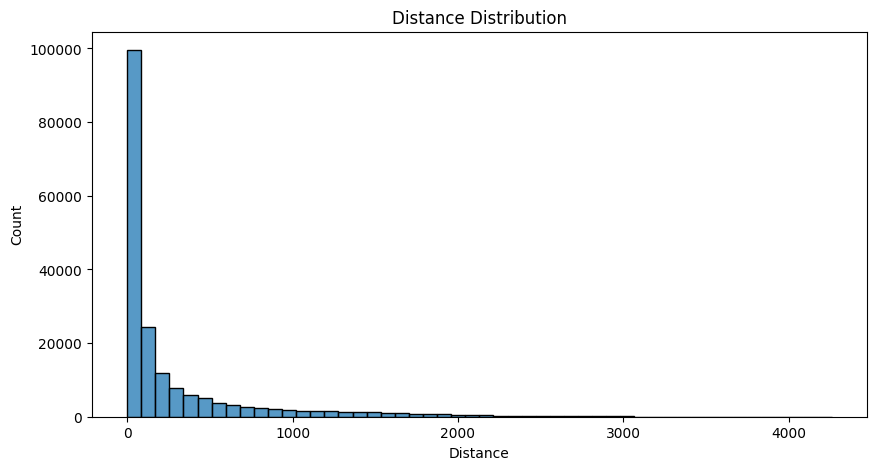

In [10]:
# Distance Distribution
plt.figure(figsize=(10,5))
sns.histplot(df['Distance'], bins=50)
plt.title("Distance Distribution")
plt.show()

### *Inference*
The distance distribution is highly right-skewed (positively skewed). Most train station records have relatively short distances, concentrated near the lower end of the scale, while only a small number of records have very large distances. This creates a long tail extending toward higher distance values, indicating the presence of a few long-distance train routes.


# Task 1.3: Basic Statistics

In [11]:
# Distance Statistics
distance_stats = df['Distance'].describe()
print(distance_stats)

count    186074.000000
mean        281.353838
std         483.743964
min           0.000000
25%          23.000000
50%          73.000000
75%         291.000000
max        4260.000000
Name: Distance, dtype: float64


In [12]:
# Number of Stops Statistics
stops_df = df.groupby('Train_No').size().reset_index(name='Num_Stops')

# Since the source station is not a stop
stops_df['Num_Stops'] = stops_df['Num_Stops'] - 1

stops_df.head()

,Train_No,Num_Stops
0,107,3
1,108,3
2,128,21
3,290,13
4,401,11


In [13]:
stops_stats = stops_df['Num_Stops'].describe()
print(stops_stats)

count    11113.000000
mean        15.743814
std         12.993123
min          1.000000
25%          7.000000
50%         14.000000
75%         21.000000
max        117.000000
Name: Num_Stops, dtype: float64


# Task 1.4: Identify missing, duplicate, or incorrect values

In [14]:
# Missing Values
df.isnull().sum()

,0
SN,0
Train_No,0
Station_Code,0
1A,0
2A,0
3A,0
SL,0
Station_Name,0
Route_Number,0
Arrival_time,0


In [15]:
# Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [16]:
# Check for negative distance values
df[df['Distance'] < 0]

,SN,Train_No,Station_Code,1A,2A,3A,SL,Station_Name,Route_Number,Arrival_time,Departure_Time,Distance


In [17]:
# Check for invalid arrival times
pd.to_datetime(
    df['Arrival_time'],
    format='%H:%M:%S',
    errors='coerce'
).isnull().sum()

np.int64(0)

In [18]:
# Check for invalid departure times
pd.to_datetime(
    df['Departure_Time'],
    format='%H:%M:%S',
    errors='coerce'
).isnull().sum()

np.int64(0)

In [19]:
# Check for distance decreasing within a Train Route
# For a train journey, distance should generally increase as stations progress.
incorrect_distance = []

for train_no, group in df.groupby('Train_No'):
    group = group.sort_values('SN')

    if (group['Distance'].diff().fillna(0) < 0).any():
        incorrect_distance.append(train_no)

print("Trains with decreasing distance:", len(incorrect_distance))

Trains with decreasing distance: 0


In [20]:
# Check for invalid sequence numbers
invalid_sn = []

for train_no, group in df.groupby('Train_No'):
    if not group['SN'].is_monotonic_increasing:
        invalid_sn.append(train_no)

print("Trains with invalid station sequence:", len(invalid_sn))

Trains with invalid station sequence: 0


# **Level 2: Data Cleaning and Feature Creation**

# Task 2.1: Handle Missing Values and Remove Duplicates

In [21]:
# Remove duplicates
df = df.drop_duplicates()

# Check missing values
print(df.isnull().sum())

SN                0
Train_No          0
Station_Code      0
1A                0
2A                0
3A                0
SL                0
Station_Name      0
Route_Number      0
Arrival_time      0
Departure_Time    0
Distance          0
dtype: int64


# Task 2.2: Convert Arrival and Departure Times

In [22]:
df['Arrival_time'] = pd.to_datetime(
    df['Arrival_time'],
    format='%H:%M:%S',
    errors='coerce'
)

df['Departure_Time'] = pd.to_datetime(
    df['Departure_Time'],
    format='%H:%M:%S',
    errors='coerce'
)

df[['Arrival_time', 'Departure_Time']].head()

,Arrival_time,Departure_Time
0,1900-01-01 00:00:00,1900-01-01 10:25:00
1,1900-01-01 11:06:00,1900-01-01 11:08:00
2,1900-01-01 11:28:00,1900-01-01 11:30:00
3,1900-01-01 12:10:00,1900-01-01 00:00:00
4,1900-01-01 00:00:00,1900-01-01 20:30:00


# Task 2.3: Calculate Total Journey Duration (Target Variable)

In [23]:
# Extract source and destination stations
source_df = df.groupby('Train_No').first().reset_index()
destination_df = df.groupby('Train_No').last().reset_index()

In [24]:
# Create duration dataframe
journey_df = pd.DataFrame()

journey_df['Train_No'] = source_df['Train_No']
journey_df['Start_Station'] = source_df['Station_Name']
journey_df['End_Station'] = destination_df['Station_Name']
journey_df['Departure_Time'] = source_df['Departure_Time']
journey_df['Arrival_Time'] = destination_df['Arrival_time']

In [25]:
# Handle Overnight Journeys
journey_df['Journey_Duration'] = (
    journey_df['Arrival_Time'] -
    journey_df['Departure_Time']
)

journey_df.loc[
    journey_df['Journey_Duration'].dt.total_seconds() < 0,
    'Journey_Duration'
] += pd.Timedelta(days=1)

In [26]:
# Convert duration into hours
journey_df['Journey_Duration_Hours'] = (
    journey_df['Journey_Duration']
    .dt.total_seconds() / 3600
)

In [27]:
journey_df.head()

,Train_No,Start_Station,End_Station,Departure_Time,Arrival_Time,Journey_Duration,Journey_Duration_Hours
0,107,SAWANTWADI R,MADGOAN JN.,1900-01-01 10:25:00,1900-01-01 12:10:00,0 days 01:45:00,1.750000
1,108,MADGOAN JN.,SAWANTWADI R,1900-01-01 20:30:00,1900-01-01 22:25:00,0 days 01:55:00,1.916667
2,128,MADGOAN JN.,CHHATRAPATI,1900-01-01 19:40:00,1900-01-01 17:45:00,0 days 22:05:00,22.083333
3,290,DELHI-SAFDAR,DELHI-SAFDAR,1900-01-01 18:30:00,1900-01-01 02:30:00,0 days 08:00:00,8.000000
4,401,AURANGABAD,VARANASI JN.,1900-01-01 21:30:00,1900-01-01 10:00:00,0 days 12:30:00,12.500000


# Task 2.4: Create Input Features

In [28]:
# Feature 1: Total Distance
distance_df = df.groupby('Train_No')['Distance'].max().reset_index()

distance_df.rename(
    columns={'Distance': 'Total_Distance'},
    inplace=True
)

In [29]:
# Feature 2: Number of Stops
stops_df = (
    df.groupby('Train_No')
    .size()
    .reset_index(name='Num_Stops')
)

stops_df['Num_Stops'] = stops_df['Num_Stops'] - 1

In [30]:
# Merge and check features
final_df = journey_df.merge(
    distance_df,
    on='Train_No'
)

final_df = final_df.merge(
    stops_df,
    on='Train_No'
)

final_df.head()

,Train_No,Start_Station,End_Station,Departure_Time,Arrival_Time,Journey_Duration,Journey_Duration_Hours,Total_Distance,Num_Stops
0,107,SAWANTWADI R,MADGOAN JN.,1900-01-01 10:25:00,1900-01-01 12:10:00,0 days 01:45:00,1.750000,78,3
1,108,MADGOAN JN.,SAWANTWADI R,1900-01-01 20:30:00,1900-01-01 22:25:00,0 days 01:55:00,1.916667,83,3
2,128,MADGOAN JN.,CHHATRAPATI,1900-01-01 19:40:00,1900-01-01 17:45:00,0 days 22:05:00,22.083333,978,21
3,290,DELHI-SAFDAR,DELHI-SAFDAR,1900-01-01 18:30:00,1900-01-01 02:30:00,0 days 08:00:00,8.000000,2694,13
4,401,AURANGABAD,VARANASI JN.,1900-01-01 21:30:00,1900-01-01 10:00:00,0 days 12:30:00,12.500000,1618,11


# **Level 3: Feature Analysis with Visuals**

# Task 3.1: Visualize how distance affects journey duration

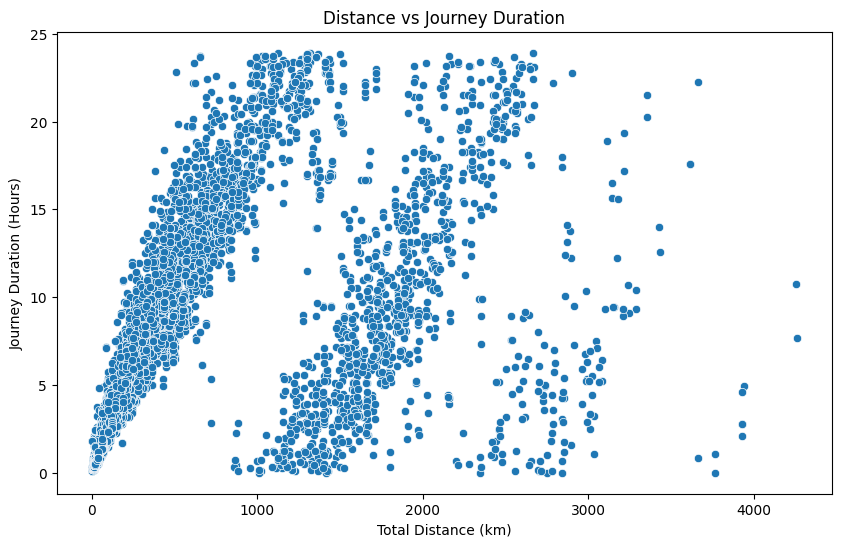

In [31]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=final_df,
    x='Total_Distance',
    y='Journey_Duration_Hours'
)

plt.title("Distance vs Journey Duration")
plt.xlabel("Total Distance (km)")
plt.ylabel("Journey Duration (Hours)")
plt.show()

### *Inference*

The scatter plot indicates a generally positive relationship between total distance and journey duration. As the distance traveled increases, the journey duration tends to increase as well. However, the presence of scattered points and clusters suggests that journey duration is also influenced by other factors such as the number of stops, train type, route conditions, and operational schedules. Overall, total distance appears to be an important predictor of journey duration.

# Task 3.2: Visualize Impact of Number of Stops on Journey Duration

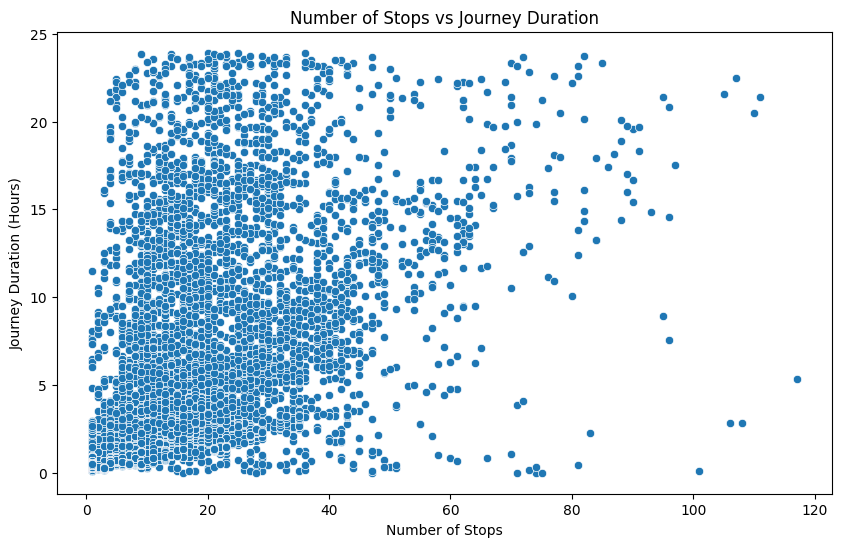

In [32]:
plt.figure(figsize=(10,6))
sns.scatterplot(
    data=final_df,
    x='Num_Stops',
    y='Journey_Duration_Hours'
)

plt.title("Number of Stops vs Journey Duration")
plt.xlabel("Number of Stops")
plt.ylabel("Journey Duration (Hours)")
plt.show()

### *Inference*

The scatter plot shows a moderate positive relationship between the number of stops and journey duration. In general, trains with more stops tend to have longer journey durations, although considerable variation exists due to factors such as route distance, train speed, and scheduling differences.

# Task 3.3: Correlation Visuals

In [33]:
# Create a correlation matrix
corr_df = final_df[
    ['Total_Distance',
     'Num_Stops',
     'Journey_Duration_Hours']
]
corr_df.corr()

,Total_Distance,Num_Stops,Journey_Duration_Hours
Total_Distance,1.000000,0.461854,0.635700
Num_Stops,0.461854,1.000000,0.500264
Journey_Duration_Hours,0.635700,0.500264,1.000000


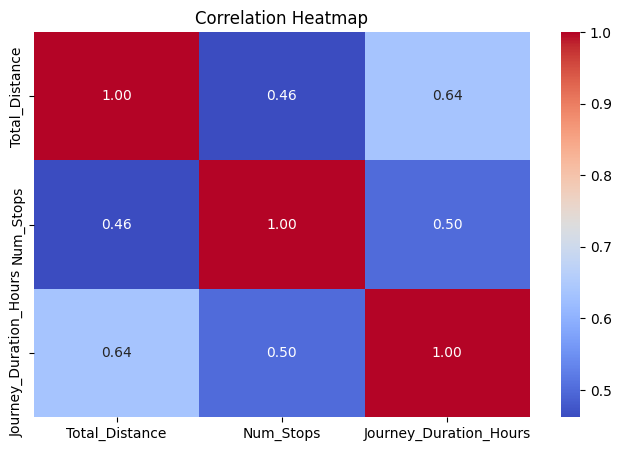

In [34]:
# Heatmap for the correlation matrix
plt.figure(figsize=(8,5))
sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)
plt.title("Correlation Heatmap")
plt.show()

### *Inference*

The correlation heatmap shows that both total distance and number of stops have a positive relationship with journey duration. Total distance has the strongest correlation with journey duration (0.64), making it the most influential feature, while the number of stops also contributes moderately (0.50) to predicting journey duration.

# Task 3.4: Build a pivot table summarizing number of stops for each train

In [35]:
pivot_table = pd.pivot_table(
    final_df,
    values='Num_Stops',
    index='Train_No',
    aggfunc='mean'
)
pivot_table.head()

,Num_Stops
Train_No,
107,3.0
108,3.0
128,21.0
290,13.0
401,11.0


# **Level 4: Model Training and Evaluation**

In [36]:
ml_df = final_df[
    ['Total_Distance',
     'Num_Stops',
     'Journey_Duration_Hours']
]

# Task 4.1: Split Dataset into Training and Testing Sets

In [37]:
# Features (X)
X = ml_df[['Total_Distance', 'Num_Stops']]

In [38]:
# Target (y)
y = ml_df['Journey_Duration_Hours']

In [39]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)
print("Training samples:", X_train.shape)
print("Testing samples:", X_test.shape)

Training samples: (8890, 2)
Testing samples: (2223, 2)


# Task 4.2: Train Linear Regression Model

In [40]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [41]:
# Model Coefficients
print("Intercept:", lr_model.intercept_)

for feature, coef in zip(X.columns, lr_model.coef_):
    print(f"{feature}: {coef}")

Intercept: 1.2529671587279667
Total_Distance: 0.004577241956041947
Num_Stops: 0.1101969107059636


# Task 4.3: Evaluate Model Using MAE and RMSE

In [42]:
# Predictions
y_pred = lr_model.predict(X_test)

In [43]:
# Metrics
mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(
    y_test,
    y_pred
))

r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

MAE : 2.54
RMSE: 3.96
R² Score: 0.45


### *Inference*

The Linear Regression model achieved an MAE of 2.54 hours and an RMSE of 3.96 hours. The R² score of 0.45 indicates that the model explains approximately 45% of the variation in journey duration. While the model captures the general relationship between journey duration, total distance, and number of stops, additional factors may influence travel time and are not included in the current dataset.

### **Retrain the model using additional features to improve the model's performance**


In [44]:
# 1. Create Departure hour feature
final_df['Departure_Hour'] = final_df['Departure_Time'].dt.hour

In [45]:
# 2. Create Arrival hour feature
final_df['Arrival_Hour'] = final_df['Arrival_Time'].dt.hour

In [46]:
# Create Distance per stop feature
final_df['Distance_Per_Stop'] = (
    final_df['Total_Distance'] /
    final_df['Num_Stops']
)

# Handle division by zero
final_df['Distance_Per_Stop'] = final_df['Distance_Per_Stop'].replace(
    [np.inf, -np.inf],
    np.nan
)
final_df['Distance_Per_Stop'] = final_df['Distance_Per_Stop'].fillna(
    final_df['Total_Distance']
)
print(final_df[['Distance_Per_Stop']].isnull().sum())

Distance_Per_Stop    0
dtype: int64


In [47]:
# Select Features
X = final_df[
    [
        'Total_Distance',
        'Num_Stops',
        'Departure_Hour',
        'Arrival_Hour',
        'Distance_Per_Stop'
    ]
]
y = final_df['Journey_Duration_Hours']

In [48]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [49]:
# Train Linear Regression
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

LinearRegression()

In [50]:
# Make Predictions
y_pred = lr_model.predict(X_test)

In [51]:
# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R² Score:", round(r2, 2))

MAE : 2.38
RMSE: 3.71
R² Score: 0.52


### *Inference*

The enhanced Linear Regression model achieved an MAE of 2.38 hours, an RMSE of 3.71 hours, and an R² score of 0.52. Compared to the previous model, the addition of engineered features improved prediction accuracy and increased the model's ability to explain variations in journey duration. This indicates that factors such as departure time and arrival time contribute to better journey duration prediction.

In [52]:
# Check Feature Importance (Coefficients)
coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_model.coef_
})
coef_df.sort_values(
    by='Coefficient',
    key=abs,
    ascending=False
)

,Feature,Coefficient
1,Num_Stops,0.153088
3,Arrival_Hour,-0.119252
2,Departure_Hour,0.112238
4,Distance_Per_Stop,0.026000
0,Total_Distance,0.002845


### *Inference*

The feature importance analysis indicates that the number of stops has the strongest positive influence on journey duration, making it the most significant predictor in the model. Departure hour and arrival hour also contribute notably to the prediction, suggesting that train schedules affect travel time. Distance per stop has a relatively small impact, while total distance shows the least influence among the selected features. Overall, the results suggest that operational factors such as stops and timing play a greater role in determining journey duration than distance alone.

# Task 4.4: Visualize Actual vs Predicted Journey Durations

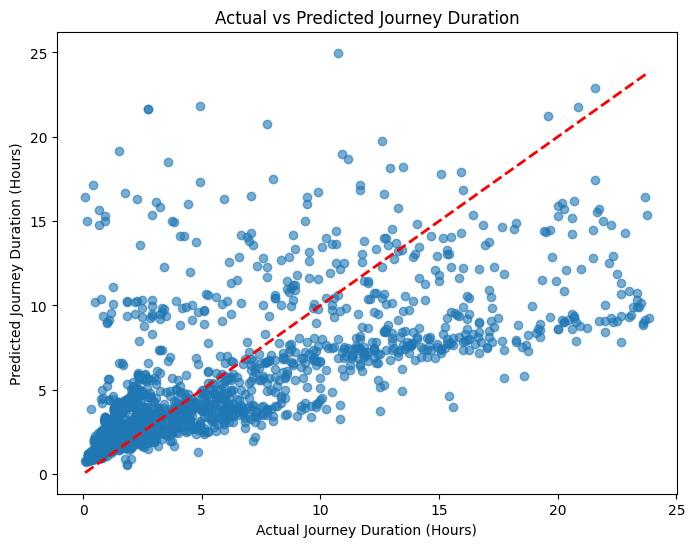

In [53]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    'r--',
    linewidth=2
)
plt.xlabel("Actual Journey Duration (Hours)")
plt.ylabel("Predicted Journey Duration (Hours)")
plt.title("Actual vs Predicted Journey Duration")

plt.show()

### *Inference*

The Actual vs Predicted plot shows a positive relationship between actual and predicted journey durations, indicating that the model captures the overall trend in the data. Many points lie close to the reference line, demonstrating reasonable prediction accuracy. However, the spread of points away from the line suggests that some prediction errors remain, likely due to additional factors affecting journey duration that are not included in the dataset.

# **Level 5: Model Comparison and User Testing**

# Task 5.1: Basic Model

In [54]:
X_basic = final_df[['Total_Distance']]
y = final_df['Journey_Duration_Hours']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_basic,
    y,
    test_size=0.2,
    random_state=42
)

basic_model = LinearRegression()
basic_model.fit(X_train_b, y_train_b)
y_pred_basic = basic_model.predict(X_test_b)

In [55]:
# Evaluate
mae_basic = mean_absolute_error(y_test_b, y_pred_basic)
rmse_basic = np.sqrt(mean_squared_error(y_test_b, y_pred_basic))
r2_basic = r2_score(y_test_b, y_pred_basic)

print("MAE :", round(mae_basic,2))
print("RMSE:", round(rmse_basic,2))
print("R² :", round(r2_basic,2))

MAE : 2.81
RMSE: 4.12
R² : 0.41


# Task 5.2: Improved Model

In [56]:
X_improved = final_df[
    [
        'Total_Distance',
        'Num_Stops',
        'Departure_Hour',
        'Arrival_Hour',
        'Distance_Per_Stop'
    ]
]

X_train_i, X_test_i, y_train_i, y_test_i = train_test_split(
    X_improved,
    y,
    test_size=0.2,
    random_state=42
)

improved_model = LinearRegression()
improved_model.fit(X_train_i, y_train_i)
y_pred_improved = improved_model.predict(X_test_i)

In [57]:
# Evaluate
mae_improved = mean_absolute_error(y_test_i, y_pred_improved)
rmse_improved = np.sqrt(mean_squared_error(y_test_i, y_pred_improved))
r2_improved = r2_score(y_test_i, y_pred_improved)

print("MAE :", round(mae_improved,2))
print("RMSE:", round(rmse_improved,2))
print("R² :", round(r2_improved,2))

MAE : 2.38
RMSE: 3.71
R² : 0.52


# Task 5.3: Model Comparison

In [60]:
# Comparison through error eetrics
comparison = pd.DataFrame({
    'Model': ['Basic Model', 'Improved Model'],
    'MAE': [mae_basic, mae_improved],
    'RMSE': [rmse_basic, rmse_improved],
    'R2 Score': [r2_basic, r2_improved]
})
comparison

,Model,MAE,RMSE,R2 Score
0,Basic Model,2.813367,4.117657,0.405063
1,Improved Model,2.375295,3.711567,0.516624


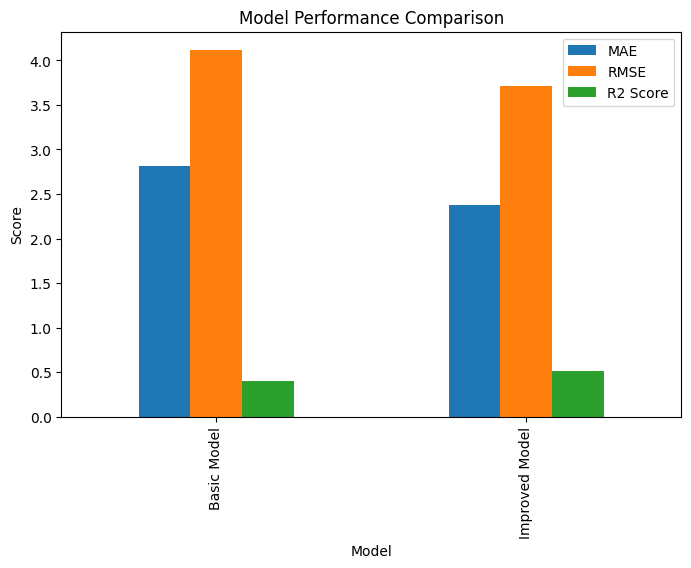

In [59]:
# Comparison Visualization
comparison.set_index('Model')[['MAE','RMSE','R2 Score']].plot(
    kind='bar',
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.show()

### *Inference*

The comparison chart shows that the improved model performs better than the basic model across all evaluation metrics. The improved model achieved lower MAE and RMSE values, indicating reduced prediction errors, and a higher R² score, demonstrating a better ability to explain variations in journey duration. This improvement confirms that incorporating additional features enhances the predictive performance of the Linear Regression model.

# Task 5.4: Select Best Model


Based on the evaluation metrics, the Improved Model was selected as the best-performing model.

- MAE decreased from 2.82 to 2.38, indicating lower average prediction error.
- RMSE decreased from 4.11 to 3.71, showing improved prediction accuracy.
- R² score increased from 0.40 to 0.52, demonstrating a better ability to explain variations in journey duration.

Therefore, the Improved Model was chosen for the final prediction system and will be used in the Web application.

# **Level 6: Final Interactive Machine Learning Project**

In [64]:
# Save the Final Model

X = final_df[
    [
        'Total_Distance',
        'Num_Stops',
        'Departure_Hour',
        'Arrival_Hour',
        'Distance_Per_Stop'
    ]
]
y = final_df['Journey_Duration_Hours']

final_model = LinearRegression()
final_model.fit(X, y)

LinearRegression()

In [66]:
with open('train_journey_model.pkl', 'wb') as file:
    pickle.dump(final_model, file)

In [71]:
# Code for Web App
import textwrap

raw_app_code_string = """
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# =========================
# Page Configuration
# =========================
st.set_page_config(
    page_title="Train Journey Duration Predictor",
    page_icon="🚆",
    layout="wide"
)

# =========================
# Load Model
# =========================
with open("train_journey_model.pkl", "rb") as file:
    model = pickle.load(file)

# =========================
# Header
# =========================
st.markdown(
'''
# 🚆 Train Journey Time Prediction System

Predict Railway journey duration using Machine Learning.
This application uses a Linear Regression model trained on Railway route and schedule data to estimate train journey duration.
'''
)

# =========================
# Model Performance
# =========================
st.subheader("📈 Model Performance")

col1, col2, col3 = st.columns(3)

with col1:
    st.metric("MAE", "2.38 hrs")

with col2:
    st.metric("RMSE", "3.71 hrs")

with col3:
    st.metric("R² Score", "0.52")

st.markdown("---")

# =========================
# Sidebar Inputs
# =========================
st.sidebar.header("🚉 Journey Details")

distance = st.sidebar.number_input(
    "Total Distance (km)",
    min_value=1.0,
    value=500.0,
    step=10.0
)

stops = st.sidebar.number_input(
    "Number of Stops",
    min_value=0,
    value=5,
    step=1
)

departure_time = st.sidebar.time_input(
    "Departure Time"
)

arrival_time = st.sidebar.time_input(
    "Arrival Time"
)

departure_hour = departure_time.hour
arrival_hour = arrival_time.hour

# =========================
# Feature Engineering
# =========================
distance_per_stop = (
    distance / stops
    if stops > 0
    else distance
)

# =========================
# Prediction Button
# =========================
if st.sidebar.button("🚆 Predict Journey Duration"):

    input_data = pd.DataFrame({
        'Total_Distance': [distance],
        'Num_Stops': [stops],
        'Departure_Hour': [departure_hour],
        'Arrival_Hour': [arrival_hour],
        'Distance_Per_Stop': [distance_per_stop]
    })

    prediction = model.predict(input_data)[0]

    # =========================
    # Prediction Result
    # =========================
    st.subheader("🎯 Prediction Result")

    col1, col2 = st.columns(2)

    with col1:
        st.metric(
            "Predicted Duration (Hours)",
            f"{prediction:.2f}"
        )

    with col2:
        hours = int(prediction)
        minutes = int((prediction - hours) * 60)

        st.metric(
            "Estimated Travel Time",
            f"{hours}h {minutes}m"
        )

    st.markdown("---")

    # =========================
    # Journey Summary
    # =========================
    st.subheader("📋 Journey Summary")

    summary_df = pd.DataFrame({
        "Feature": [
            "Total Distance (km)",
            "Number of Stops",
            "Departure Hour",
            "Arrival Hour",
            "Distance Per Stop"
        ],
        "Value": [
            distance,
            stops,
            departure_hour,
            arrival_hour,
            round(distance_per_stop, 2)
        ]
    })

    st.dataframe(
        summary_df,
        use_container_width=True
    )

    # =========================
    # Visualization
    # =========================
    st.subheader("📊 Journey Duration Visualization")

    fig, ax = plt.subplots(figsize=(7, 4))

    ax.bar(
        ["Predicted Duration"],
        [prediction]
    )

    ax.set_ylabel("Hours")
    ax.set_title("Estimated Journey Duration")

    st.pyplot(fig)

# =========================
# About Model
# =========================
st.markdown("---")

st.subheader("🤖 Model Information")

st.info(
'''
Model: Linear Regression

Features Used:
• Total Distance
• Number of Stops
• Departure Hour
• Arrival Hour
• Distance Per Stop

Target Variable:
• Journey Duration (Hours)

Performance:
• MAE = 2.38 Hours
• RMSE = 3.71 Hours
• R² Score = 0.52
'''
)

# =========================
# Footer
# =========================
st.markdown("---")

st.markdown(
'''
### 👨‍💻 Developed By

Harsh Verma

Machine Learning-Based Train Journey Time Prediction System
'''
)
"""

app_code = textwrap.dedent(raw_app_code_string)

with open("app.py", "w") as f:
    f.write(app_code)

print("app.py created successfully!")
